In [1]:
import pandas as pd
import numpy as np
import re

import plotly.graph_objects as go

In [4]:
from pathlib import Path
import pandas as pd
import numpy as np
import re

RESULT_DIR = (
    Path.home()
    / "Documents"
    / "Master Degree in Sport Analytics"
    / "2. Management and Architecture of Sports Database"
    / "selenium wire"
    / "Result_SerieA_25_26"
)

print("Result dir:", RESULT_DIR)
print("Esiste?", RESULT_DIR.exists())

Result dir: /Users/ricki/Documents/Master Degree in Sport Analytics/2. Management and Architecture of Sports Database/selenium wire/Result_SerieA_25_26
Esiste? True


In [5]:
def find_csv_files(root: Path, recursive=True):
    root = root.expanduser().resolve()
    if not root.exists():
        raise FileNotFoundError(f"Cartella non trovata: {root}")

    pattern = "**/*.csv" if recursive else "*.csv"
    files = list(root.glob(pattern)) + list(root.glob(pattern.replace(".csv", ".CSV")))
    files = [f for f in files if "-checkpoint" not in f.name]
    return sorted(set(files))

paths = find_csv_files(RESULT_DIR)
print("CSV trovati:", len(paths))
print("Primi 5:", [p.name for p in paths[:5]])

CSV trovati: 200
Primi 5: ['10_Cremonese_Juventus_digmzny5no6kxh6hfopalgahg.csv', '10_Fiorentina_Lecce_diuxkzq1t6j5r3b8myu04i3h0.csv', '10_Lazio_Cagliari_dj93wlc4y6a5z30ns89tmayac.csv', '10_Milan_Roma_djnhnvs0hjjv7p1rlkt1eizh0.csv', '10_Napoli_Como_dk1y2p3cuhqk9g9jrvfmk6784.csv']


In [6]:
def load_events(paths):
    dfs = []
    for p in paths:
        try:
            df = pd.read_csv(p)
            df["source_file"] = p.name
            dfs.append(df)
        except Exception as e:
            print(f"[SKIP] {p.name} -> {e}")

    if not dfs:
        raise ValueError("Nessun CSV caricato.")

    return pd.concat(dfs, ignore_index=True)

events_raw = load_events(paths)
print("Righe:", len(events_raw))

Righe: 332499


In [7]:
def standardize_schema(df):
    out = df.copy()
    out = out.rename(columns={
        "event": "type",
        "period_id": "period",
        "time_min": "minute",
        "time_sec": "second",
        "team_name": "team",
        "represented_qualifiers": "qualifiers_raw",
        "non_represented_qualifiers": "qualifiers_raw_2",
        "Pass End X": "end_x",
        "Pass End Y": "end_y",
    })

    if "end_x" not in out.columns:
        out["end_x"] = np.nan
    if "end_y" not in out.columns:
        out["end_y"] = np.nan

    return out

events_std = standardize_schema(events_raw)
events_std[["type","team","minute","second","x","y","end_x","end_y"]].head(3)

,type,team,minute,second,x,y,end_x,end_y
0,Team setp up,US Cremonese,0,0,0.0,0.0,NaN,NaN
1,Team setp up,Juventus FC,0,0,0.0,0.0,NaN,NaN
2,Start,US Cremonese,0,0,0.0,0.0,NaN,NaN


In [8]:
def clean_and_sort(df):
    out = df.copy()

    for c in ["x","y","end_x","end_y","minute","second","period"]:
        out[c] = pd.to_numeric(out[c], errors="coerce")

    out["x"] = out["x"].clip(0, 100)
    out["y"] = out["y"].clip(0, 100)
    out["end_x"] = out["end_x"].clip(0, 100)
    out["end_y"] = out["end_y"].clip(0, 100)

    out = out.sort_values(
        ["match_id","period","minute","second","event_id"],
        kind="mergesort"
    ).reset_index(drop=True)

    return out

events_clean0 = clean_and_sort(events_std)

In [9]:
def _qtext(df):
    return (
        df["qualifiers_raw"].fillna("").astype(str)
        + " ; "
        + df["qualifiers_raw_2"].fillna("").astype(str)
    ).str.lower()

def add_phase_tags(df):
    out = df.copy()
    qt = _qtext(out)

    is_corner = qt.str.contains("corner")
    is_fk = qt.str.contains("free kick")
    is_throw = qt.str.contains("throw in")
    is_pen = qt.str.contains("penalty")
    is_gk = qt.str.contains("goal kick")

    out["restart_type"] = np.select(
        [is_pen, is_corner, is_fk, is_throw, is_gk],
        ["penalty","corner","free_kick","throw_in","goal_kick"],
        default="none"
    )

    is_set_piece = out["restart_type"] != "none"
    is_transition = qt.str.contains("fast break") | qt.str.contains("counter")
    is_admin = out["type"].isin(["Start","End","Team setp up","Resume"])

    out["phase_of_play"] = np.select(
        [is_set_piece, is_transition, ~is_admin],
        ["set_piece","transition","open_play"],
        default="unknown"
    )

    return out

events_clean = add_phase_tags(events_clean0)
events_clean["phase_of_play"].value_counts()

phase_of_play
open_play     310386
set_piece      19324
unknown         2400
transition       389
Name: count, dtype: int64

In [10]:
def build_possessions(df):
    out = df.copy()

    out["is_shot"] = out["type"].isin(["Miss","Post","Saved Shot","Goal"])
    out["is_stop"] = out["type"].isin(["Out","Foul","Offside Pass"])
    out["is_failed_pass"] = (out["type"]=="Pass") & (out["outcome"]==0)

    out["next_team"] = out.groupby(["match_id","period"])["team"].shift(-1)
    out["possession_change"] = (
        out["next_team"].notna()
        & (out["next_team"] != out["team"])
        & (out["is_shot"] | out["is_stop"] | out["is_failed_pass"])
    )

    out["possession_id"] = out.groupby(["match_id","period"])["possession_change"].cumsum()

    out["possession_team"] = out.groupby(
        ["match_id","period","possession_id"]
    )["team"].transform("first")

    return out

events_poss = build_possessions(events_clean)
events_poss[["team","type","possession_id","possession_team"]].head(20)

,team,type,possession_id,possession_team
0,Pisa Sporting Club,Start,0,Pisa Sporting Club
1,Atalanta Bergamasca Calcio,Start,0,Pisa Sporting Club
2,Atalanta Bergamasca Calcio,Pass,0,Pisa Sporting Club
3,Atalanta Bergamasca Calcio,Pass,0,Pisa Sporting Club
4,Atalanta Bergamasca Calcio,Pass,0,Pisa Sporting Club
5,Atalanta Bergamasca Calcio,Pass,0,Pisa Sporting Club
6,Atalanta Bergamasca Calcio,Pass,0,Pisa Sporting Club
7,Atalanta Bergamasca Calcio,Pass,0,Pisa Sporting Club
8,Atalanta Bergamasca Calcio,Pass,0,Pisa Sporting Club
9,Atalanta Bergamasca Calcio,Pass,0,Pisa Sporting Club


In [11]:
events_poss["outcome"].value_counts(dropna=False).head(20)

outcome
1    252237
0     80262
Name: count, dtype: int64

In [12]:
# GRID CONFIG
N_X = 12
N_Y = 8

def assign_zone(df, n_x=N_X, n_y=N_Y):
    out = df.copy()

    out["zone_x"] = (out["x"] / (100 / n_x)).astype(int).clip(0, n_x-1)
    out["zone_y"] = (out["y"] / (100 / n_y)).astype(int).clip(0, n_y-1)

    out["zone_id"] = out["zone_y"] * n_x + out["zone_x"]
    return out

events_zoned = assign_zone(events_poss)

events_zoned[["x","y","zone_x","zone_y","zone_id"]].head()

,x,y,zone_x,zone_y,zone_id
0,0.0,0.0,0,0,0
1,0.0,0.0,0,0,0
2,50.1,50.2,6,4,54
3,35.5,55.8,4,4,52
4,34.2,37.4,4,2,28


In [13]:
def is_shot_event(df):
    return df["type"].isin([
        "Miss",
        "Post",
        "Saved Shot",
        "Goal",
        "Chance missed",
        "Temp_Attempt",
        "Temp_Goal"
    ])

events_zoned["is_shot"] = is_shot_event(events_zoned)

events_zoned["is_shot"].value_counts()

is_shot
False    327500
True       4999
Name: count, dtype: int64

In [14]:
LOOKAHEAD = 10

def label_shot_within_n(df, n=LOOKAHEAD):
    out = df.copy()
    out["shot_within_n"] = 0

    for (m,p,poss), g in out.groupby(["match_id","period","possession_id"]):
        idx = g.index.to_list()
        shots = g["is_shot"].values

        for i in range(len(idx)):
            if shots[i+1 : i+1+n].any():
                out.loc[idx[i], "shot_within_n"] = 1

    return out

events_labeled = label_shot_within_n(events_zoned)

events_labeled["shot_within_n"].value_counts()

shot_within_n
0    324950
1      7549
Name: count, dtype: int64

In [15]:
zone_shot_prob = (
    events_labeled
    .groupby("zone_id")
    .agg(
        n_events=("shot_within_n", "count"),
        n_shots=("shot_within_n", "sum")
    )
)

zone_shot_prob["p_shot"] = zone_shot_prob["n_shots"] / zone_shot_prob["n_events"]
zone_shot_prob = zone_shot_prob.fillna(0)

zone_shot_prob.head()

,n_events,n_shots,p_shot
zone_id,,,
0,19713,284,0.014407
1,2259,31,0.013723
2,2809,32,0.011392
3,4970,61,0.012274
4,5651,55,0.009733


In [16]:
events_epv = events_labeled.merge(
    zone_shot_prob[["p_shot"]],
    on="zone_id",
    how="left"
)

events_epv["epv"] = events_epv["p_shot"]
events_epv[["zone_id","epv"]].head()

,zone_id,epv
0,0,0.014407
1,0,0.014407
2,54,0.019456
3,52,0.014330
4,28,0.015732


In [17]:
def compute_delta_epv(df):
    out = df.copy()
    out["epv_next"] = out.groupby(
        ["match_id","period","possession_id"]
    )["epv"].shift(-1)

    out["delta_epv"] = out["epv_next"] - out["epv"]
    return out

events_epv = compute_delta_epv(events_epv)

events_epv[["type","zone_id","epv","epv_next","delta_epv"]].head(10)

,type,zone_id,epv,epv_next,delta_epv
0,Start,0,0.014407,0.014407,0.000000
1,Start,0,0.014407,0.019456,0.005050
2,Pass,54,0.019456,0.014330,-0.005127
3,Pass,52,0.014330,0.015732,0.001403
4,Pass,28,0.015732,0.015102,-0.000631
5,Pass,39,0.015102,0.013239,-0.001863
6,Pass,16,0.013239,0.016499,0.003259
7,Pass,17,0.016499,0.016058,-0.000441
8,Pass,40,0.016058,0.013242,-0.002816
9,Pass,75,0.013242,NaN,NaN


In [18]:
df_bologna = events_epv[
    (events_epv["team"].str.contains("Bologna", case=False, na=False)) &
    (events_epv["phase_of_play"] == "open_play")
].copy()

print(len(df_bologna))

15720


In [19]:
from mplsoccer import VerticalPitch
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt
from mplsoccer import Pitch

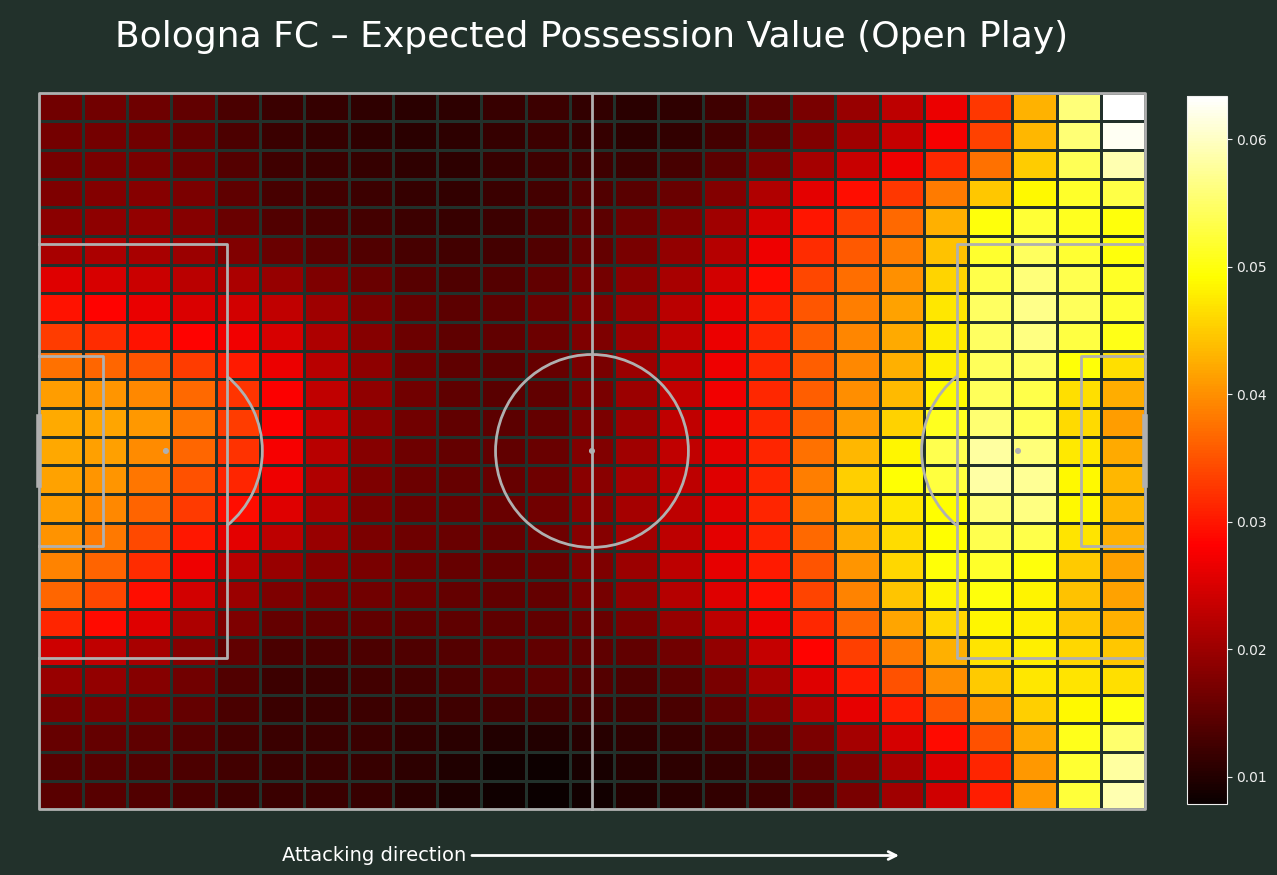

In [20]:
from mplsoccer import Pitch
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt
import numpy as np

pitch = Pitch(pitch_type='opta', line_zorder=2, pitch_color='#22312b')

fig, axs = pitch.grid(
    endnote_height=0.03, endnote_space=0,
    grid_width=0.88, left=0.025,
    title_height=0.06, title_space=0,
    axis=False, grid_height=0.86
)
fig.set_facecolor('#22312b')

# EPV mean per bin
bin_stat = pitch.bin_statistic(
    df_bologna.x, df_bologna.y,
    values=df_bologna.epv,
    statistic='mean',
    bins=(25, 25)
)

# 1) riempi i NaN (bin senza eventi) -> 0
stat = bin_stat["statistic"]
stat = np.nan_to_num(stat, nan=0.0)

# 2) smoothing
stat = gaussian_filter(stat, sigma=1)

bin_stat["statistic"] = stat

pcm = pitch.heatmap(
    bin_stat, ax=axs["pitch"],
    cmap="hot",
    edgecolors="#22312b"
)

# colorbar
ax_cbar = fig.add_axes((0.915, 0.093, 0.03, 0.786))
cbar = plt.colorbar(pcm, cax=ax_cbar)
cbar.outline.set_edgecolor('#efefef')
cbar.ax.yaxis.set_tick_params(color='#efefef')
plt.setp(cbar.ax.get_yticklabels(), color='#efefef')

axs["title"].text(
    0.5, 0.5,
    "Bologna FC – Expected Possession Value (Open Play)",
    color="white", va="center", ha="center",
    fontsize=26
)

# Freccia direzionale (attacco verso destra)
axs["endnote"].annotate(
    "Attacking direction",
    xy=(0.78, 0.35), xycoords="axes fraction",
    xytext=(0.22, 0.35), textcoords="axes fraction",
    arrowprops=dict(arrowstyle="->", color="white", lw=2),
    color="white", ha="left", va="center", fontsize=14
)

plt.show()

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mplsoccer import Pitch
from scipy.ndimage import gaussian_filter

# ----------------------------
# CONFIG
# ----------------------------
# ----------------------------
# CONFIG
# ----------------------------
RESULT_DIR = (
    Path.home()
    / "Documents"
    / "Master Degree in Sport Analytics"
    / "2. Management and Architecture of Sports Database"
    / "selenium wire"
    / "Result_SerieA_25_26_CSVs"
)

print("Result dir:", RESULT_DIR)
print("Esiste?", RESULT_DIR.exists())

ONLY_OPEN_PLAY = True
SMOOTH_SIGMA = 1
HIGH_REGAIN_X_MIN = 66.7  # zona alta (attacco -> destra)

PRESSURE_TYPES = ["Tackle", "Challenge", "Interception", "Blocked Pass", "Ball recovery"]
HIGH_REGAIN_TYPES = ["Ball recovery", "Interception", "Tackle"]

SHOT_TYPES = ["Goal", "Saved Shot", "Miss", "Post"]


# ----------------------------
# 1) Find files (tutti i csv)
# ----------------------------
def find_event_files(root: Path):
    files = sorted(root.rglob("*.csv"))
    files = [f for f in files if "-checkpoint" not in f.name.lower()]
    if not files:
        raise FileNotFoundError(f"Nessun CSV trovato in {root}")
    return files


# ----------------------------
# 2) Load + standardize
# ----------------------------
def load_events(paths):
    dfs = []
    for p in paths:
        df = pd.read_csv(p)
        df["source_file"] = p.name
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)


def standardize(df):
    out = df.copy()
    out = out.rename(columns={
        "event": "type",
        "period_id": "period",
        "time_min": "minute",
        "time_sec": "second",
        "team_name": "team",
        "represented_qualifiers": "qualifiers_raw",
        "non_represented_qualifiers": "qualifiers_raw_2",
    })

    # numerici
    for c in ["x", "y", "minute", "second", "period", "outcome", "match_id", "event_id"]:
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors="coerce")

    if "x" in out.columns:
        out["x"] = out["x"].clip(0, 100)
    if "y" in out.columns:
        out["y"] = out["y"].clip(0, 100)

    sort_cols = [c for c in ["match_id", "period", "minute", "second", "event_id"] if c in out.columns]
    if sort_cols:
        out = out.sort_values(sort_cols, kind="mergesort").reset_index(drop=True)

    return out


# ----------------------------
# 3) Phase tagging (open_play) via qualifiers
# ----------------------------
def qtext(df):
    q1 = df.get("qualifiers_raw", pd.Series("", index=df.index)).fillna("").astype(str)
    q2 = df.get("qualifiers_raw_2", pd.Series("", index=df.index)).fillna("").astype(str)
    return (q1 + " ; " + q2).str.lower()


def add_phase_of_play(ev):
    qt = qtext(ev)

    is_corner  = qt.str.contains(r"\bcorner\b")
    is_fk      = qt.str.contains(r"\bfree kick\b") | qt.str.contains(r"\bdirect free\b") | qt.str.contains(r"\bindirect free\b")
    is_throwin = qt.str.contains(r"\bthrow in\b") | qt.str.contains(r"\bthrow-in\b")
    is_pen     = qt.str.contains(r"\bpenalty\b")
    is_gk      = qt.str.contains(r"\bgoal kick\b") | qt.str.contains(r"\bkick from hands\b")
    is_out     = qt.str.contains(r"\bout of play\b") | (ev["type"] == "Out")

    restart_type = np.select(
        [is_pen, is_corner, is_fk, is_throwin, is_gk, is_out],
        ["penalty", "corner", "free_kick", "throw_in", "goal_kick", "out_of_play"],
        default="none"
    )

    is_admin = ev["type"].isin(["Start","End","Team setp up","Resume","Formation change",
                                "Player on","Player Off","Substitution"])
    is_set_piece = np.isin(restart_type, ["penalty","corner","free_kick","throw_in","goal_kick"])
    is_open_play = (~is_set_piece) & (~is_admin) & (~is_out)

    ev["phase_of_play"] = np.select([is_set_piece, is_open_play], ["set_piece","open_play"], default="unknown")
    return ev


# ----------------------------
# 4) Normalize: team attacca sempre a destra (per match+period)
# ----------------------------
def normalize_attack_right_using_shots(df_team):
    out = df_team.copy()
    out["x"] = pd.to_numeric(out["x"], errors="coerce")
    out["y"] = pd.to_numeric(out["y"], errors="coerce")

    # quali righe sono tiri
    is_shot = out["type"].isin(SHOT_TYPES)

    keys = ["match_id", "period"]

    # conteggio tiri per match_id+period
    shot_count = out.loc[is_shot].groupby(keys).size()

    # media x dei tiri per match_id+period
    shot_mean_x = out.loc[is_shot].groupby(keys)["x"].mean()

    # flip = almeno 3 tiri e media x < 50
    flip = (shot_count >= 3) & (shot_mean_x < 50)

    # trasformo in tabella mergeabile
    flip_flags = flip.reset_index()
    flip_flags.columns = ["match_id", "period", "flip"]

    # merge
    out = out.merge(flip_flags, on=["match_id", "period"], how="left")

    out["flip"] = out["flip"].map(lambda x: bool(x) if pd.notna(x) else False)

    # applico flip solo su x
    out.loc[out["flip"], "x"] = 100 - out.loc[out["flip"], "x"]

    return out.drop(columns=["flip"])


# ----------------------------
# 5) Plot helper: positional heatmap
# ----------------------------
def plot_positional_heatmap(df, title, cmap="coolwarm", normalize=True, show_points=True, show_labels=True):
    pitch = Pitch(pitch_type='opta', line_zorder=2, pitch_color='#22312b', line_color='white')
    fig, axs = pitch.grid(
        endnote_height=0.06, endnote_space=0,
        grid_width=0.88, left=0.025,
        title_height=0.08, title_space=0,
        axis=False, grid_height=0.80
    )
    fig.set_facecolor('#22312b')

    bin_stat = pitch.bin_statistic_positional(
        df.x, df.y,
        statistic='count',
        positional='full',
        normalize=normalize
    )

    for bs in bin_stat:
        stat = np.nan_to_num(bs["statistic"], nan=0.0)
        if SMOOTH_SIGMA and SMOOTH_SIGMA > 0:
            stat = gaussian_filter(stat, sigma=SMOOTH_SIGMA)
        bs["statistic"] = stat

    pcms = pitch.heatmap_positional(
        bin_stat,
        ax=axs["pitch"],
        cmap=cmap,
        edgecolors="#22312b"
    )

    if show_points:
        pitch.scatter(df.x, df.y, ax=axs["pitch"], s=8, color="white", alpha=0.45, linewidth=0)

    if show_labels:
        fmt = "{:.0%}" if normalize else "{:.0f}"
        pitch.label_heatmap(bin_stat, ax=axs["pitch"], color="white", fontsize=12,
                            ha="center", va="center", str_format=fmt)

    mappable = pcms[0] if isinstance(pcms, (list, tuple)) else pcms
    ax_cbar = fig.add_axes((0.915, 0.15, 0.03, 0.70))
    cbar = plt.colorbar(mappable, cax=ax_cbar)
    cbar.outline.set_edgecolor('#efefef')
    cbar.ax.yaxis.set_tick_params(color='#efefef')
    plt.setp(cbar.ax.get_yticklabels(), color='#efefef')

    axs["title"].text(0.5, 0.5, title, color="white", va="center", ha="center", fontsize=22)
    axs["endnote"].annotate(
        "Attacking direction",
        xy=(0.78, 0.35), xycoords="axes fraction",
        xytext=(0.22, 0.35), textcoords="axes fraction",
        arrowprops=dict(arrowstyle="->", color="white", lw=2),
        color="white", ha="left", va="center", fontsize=14
    )
    plt.show()


# ----------------------------
# 6) Main runner: team + (optional) match_id
# ----------------------------
def run_team_match_analysis(team_str, match_id=None):
    paths = find_event_files(RESULT_DIR)
    raw = load_events(paths)
    ev = standardize(raw)
    ev = add_phase_of_play(ev)

    # filtro squadra
    # --- REPLACE the old str.contains filter with this ---
    # normalize team names in the dataframe
    ev["_team_norm"] = (
    ev["team"]
      .astype(str)
      .str.lower()
      .str.replace(r"\s+", " ", regex=True)
      .str.strip()
)

    # normalize what the user typed
    team_norm = str(team_str).lower().strip()

    # handle common aliases (key fix for Milan)
    ALIASES = {
    "milan": "ac milan",
    "ac milan": "ac milan",
}

    team_norm = ALIASES.get(team_norm, team_norm)

    # filter with EXACT match (no more doubling)
    df_team = ev[ev["_team_norm"].eq(team_norm)].copy()

    # filtro partita (opzionale)
    if match_id is not None:
        df_team = df_team[df_team["match_id"] == match_id].copy()

    # open play
    if ONLY_OPEN_PLAY:
        df_team = df_team[df_team["phase_of_play"] == "open_play"].copy()

    if df_team.empty:
        raise ValueError(f"Nessun evento trovato per team='{team_str}' e match_id='{match_id}'")

    # normalizza direzione (fondamentale per high regains x>=66.7)
    df_team = normalize_attack_right_using_shots(df_team)

    # datasets
    df_pressure = df_team[df_team["type"].isin(PRESSURE_TYPES)].copy()

    df_high_regains = df_team[df_team["type"].isin(HIGH_REGAIN_TYPES)].copy()
    if "outcome" in df_high_regains.columns:
        is_tackle = df_high_regains["type"].eq("Tackle")
        df_high_regains = df_high_regains[~is_tackle | (df_high_regains["outcome"] == 1)].copy()

    df_high_regains = df_high_regains[df_high_regains["x"] >= HIGH_REGAIN_X_MIN].copy()

    # titoli
    suffix = f"(match_id={match_id})" if match_id is not None else "(all matches)"
    title_team = team_str.strip()

    print(f"[{title_team}] eventi:", len(df_team), "| match:", df_team["match_id"].nunique())
    print("Pressure attempts:", len(df_pressure))
    print("High regains:", len(df_high_regains))

    # plot
    plot_positional_heatmap(
        df_pressure,
        title=f"{title_team} – Pressure Attempts (Open Play) {suffix}",
        cmap="coolwarm",
        normalize=True
    )

    plot_positional_heatmap(
        df_high_regains,
        title=f"{title_team} – High Regains (x ≥ {HIGH_REGAIN_X_MIN:.1f}, Open Play) {suffix}",
        cmap="coolwarm",
        normalize=False
    )

    return

Result dir: /Users/ricki/Documents/Master Degree in Sport Analytics/2. Management and Architecture of Sports Database/selenium wire/Result_SerieA_25_26_CSVs
Esiste? True


[Bologna FC 1909] eventi: 13430 | match: 0
Pressure attempts: 1312
High regains: 84


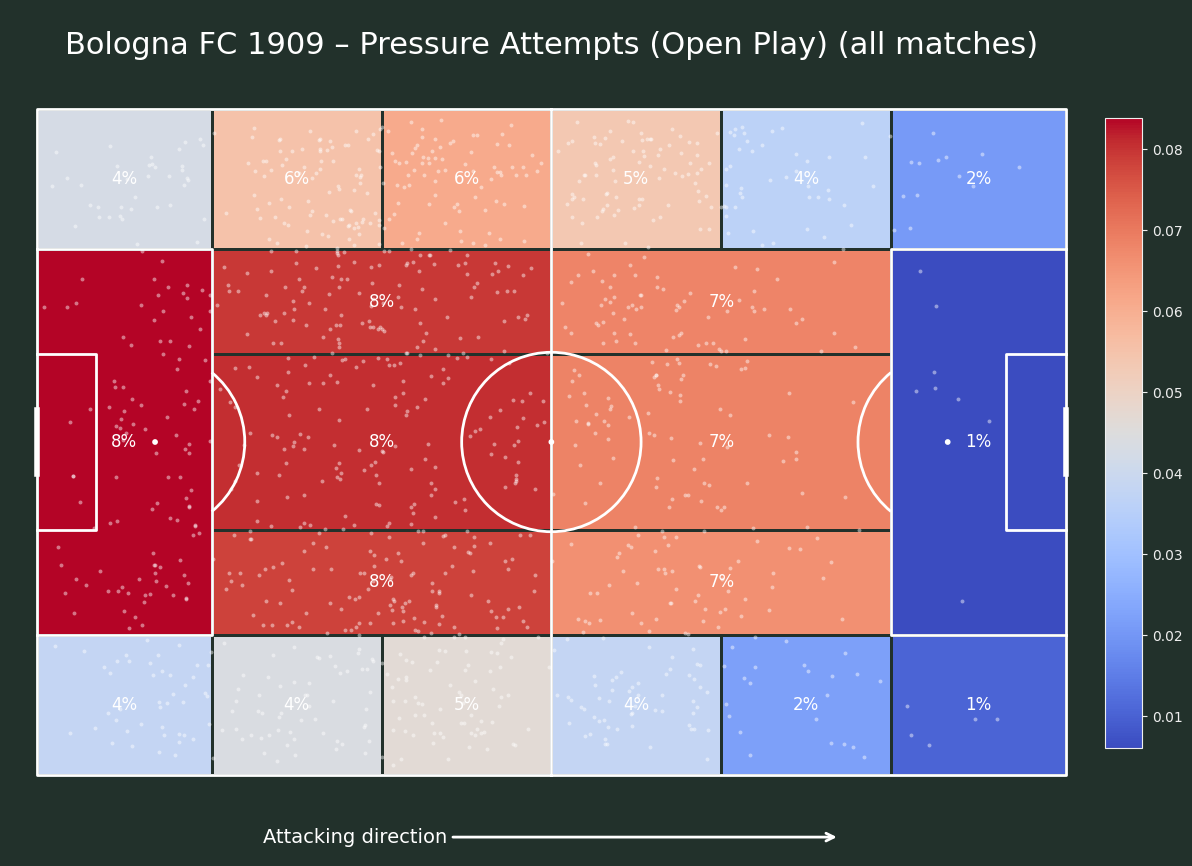

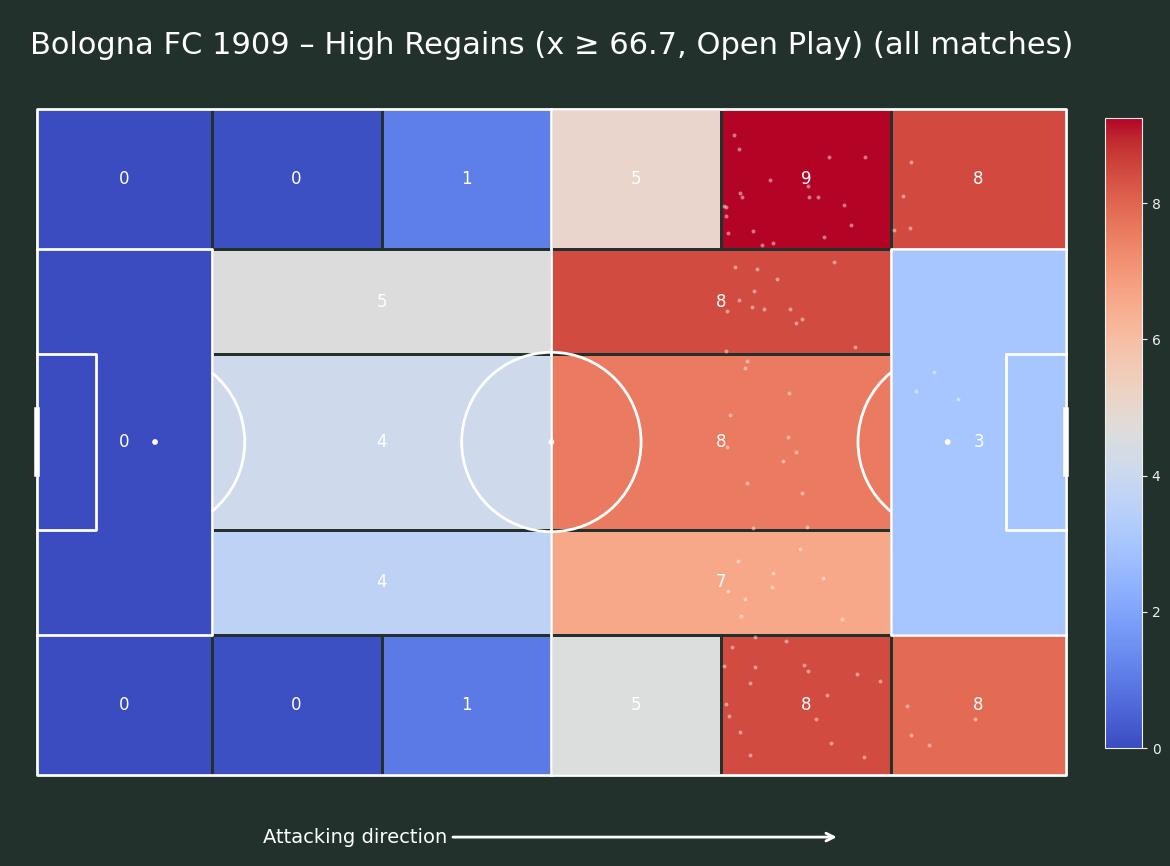

In [ ]:
run_team_match_analysis("Bologna FC 1909")

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd

# ----------------------------
# CONFIG
# ----------------------------
# ----------------------------
# CONFIG
# ----------------------------
RESULT_DIR = (
    Path.home()
    / "Documents"
    / "Master Degree in Sport Analytics"
    / "2. Management and Architecture of Sports Database"
    / "selenium wire"
    / "Result_SerieA_25_26_CSVs"
)

print("Result dir:", RESULT_DIR)
print("Esiste?", RESULT_DIR.exists())

ONLY_OPEN_PLAY = True
HIGH_REGAIN_X_MIN = 66.7

PRESSURE_TYPES = ["Tackle", "Challenge", "Interception", "Blocked Pass", "Ball recovery"]
HIGH_REGAIN_TYPES = ["Ball recovery", "Interception", "Tackle"]
SHOT_TYPES = ["Goal", "Saved Shot", "Miss", "Post"]


# ----------------------------
# 1) Find files
# ----------------------------
def find_event_files(root: Path):
    files = sorted(root.rglob("*.csv"))
    files = [f for f in files if "-checkpoint" not in f.name.lower()]
    if not files:
        raise FileNotFoundError(f"Nessun CSV trovato in {root}")
    return files


# ----------------------------
# 2) Load + standardize
# ----------------------------
def load_events(paths):
    dfs = []
    for p in paths:
        df = pd.read_csv(p)
        df["source_file"] = p.name
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)


def standardize(df):
    out = df.copy()
    out = out.rename(columns={
        "event": "type",
        "period_id": "period",
        "time_min": "minute",
        "time_sec": "second",
        "team_name": "team",
        "represented_qualifiers": "qualifiers_raw",
        "non_represented_qualifiers": "qualifiers_raw_2",
    })

    # numerici
    for c in ["x", "y", "minute", "second", "period", "outcome", "match_id", "event_id"]:
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors="coerce")

    if "x" in out.columns:
        out["x"] = out["x"].clip(0, 100)
    if "y" in out.columns:
        out["y"] = out["y"].clip(0, 100)

    sort_cols = [c for c in ["match_id", "period", "minute", "second", "event_id"] if c in out.columns]
    if sort_cols:
        out = out.sort_values(sort_cols, kind="mergesort").reset_index(drop=True)

    return out


# ----------------------------
# 3) Phase tagging (open_play)
# ----------------------------
def qtext(df):
    q1 = df.get("qualifiers_raw", pd.Series("", index=df.index)).fillna("").astype(str)
    q2 = df.get("qualifiers_raw_2", pd.Series("", index=df.index)).fillna("").astype(str)
    return (q1 + " ; " + q2).str.lower()


def add_phase_of_play(ev):
    qt = qtext(ev)

    is_corner  = qt.str.contains(r"\bcorner\b")
    is_fk      = qt.str.contains(r"\bfree kick\b") | qt.str.contains(r"\bdirect free\b") | qt.str.contains(r"\bindirect free\b")
    is_throwin = qt.str.contains(r"\bthrow in\b") | qt.str.contains(r"\bthrow-in\b")
    is_pen     = qt.str.contains(r"\bpenalty\b")
    is_gk      = qt.str.contains(r"\bgoal kick\b") | qt.str.contains(r"\bkick from hands\b")
    is_out     = qt.str.contains(r"\bout of play\b") | (ev["type"] == "Out")

    restart_type = np.select(
        [is_pen, is_corner, is_fk, is_throwin, is_gk, is_out],
        ["penalty", "corner", "free_kick", "throw_in", "goal_kick", "out_of_play"],
        default="none"
    )

    is_admin = ev["type"].isin(["Start","End","Team setp up","Resume","Formation change",
                                "Player on","Player Off","Substitution"])
    is_set_piece = np.isin(restart_type, ["penalty","corner","free_kick","throw_in","goal_kick"])
    is_open_play = (~is_set_piece) & (~is_admin) & (~is_out)

    ev["phase_of_play"] = np.select([is_set_piece, is_open_play], ["set_piece","open_play"], default="unknown")
    return ev


# ----------------------------
# 4) Normalize direction per team (match+period) via shots
# ----------------------------
def normalize_attack_right_using_shots(df_team):
    out = df_team.copy()
    out["x"] = pd.to_numeric(out["x"], errors="coerce")
    out["y"] = pd.to_numeric(out["y"], errors="coerce")

    is_shot = out["type"].isin(SHOT_TYPES)
    keys = ["match_id", "period"]

    shot_count = out.loc[is_shot].groupby(keys).size()
    shot_mean_x = out.loc[is_shot].groupby(keys)["x"].mean()

    flip = (shot_count >= 3) & (shot_mean_x < 50)
    flip_flags = flip.reset_index()
    flip_flags.columns = ["match_id", "period", "flip"]

    out = out.merge(flip_flags, on=["match_id", "period"], how="left")
    out["flip"] = out["flip"].map(lambda x: bool(x) if pd.notna(x) else False)

    out.loc[out["flip"], "x"] = 100 - out.loc[out["flip"], "x"]

    return out.drop(columns=["flip"])


# ----------------------------
# 5) TEAM SUMMARY TABLE (NO PLOTS)
# ----------------------------
def build_team_summary_table():
    paths = find_event_files(RESULT_DIR)
    raw = load_events(paths)
    ev = standardize(raw)
    ev = add_phase_of_play(ev)

    # filtro open play (globale)
    if ONLY_OPEN_PLAY:
        ev = ev[ev["phase_of_play"] == "open_play"].copy()

    # tolgo team vuoti
    ev["team"] = ev.get("team", pd.Series(index=ev.index, dtype="object")).astype(str)
    ev = ev[ev["team"].notna() & (ev["team"].str.strip() != "")].copy()

    # normalizzo per ogni squadra separatamente (come nel tuo approccio)
    tables = []
    for team_name, df_team in ev.groupby("team", sort=True):
        df_team = normalize_attack_right_using_shots(df_team)

        n_events = len(df_team)
        n_matches = df_team["match_id"].nunique() if "match_id" in df_team.columns else np.nan

        df_pressure = df_team[df_team["type"].isin(PRESSURE_TYPES)]
        n_pressure = len(df_pressure)

        df_hr = df_team[df_team["type"].isin(HIGH_REGAIN_TYPES)].copy()
        if "outcome" in df_hr.columns:
            is_tackle = df_hr["type"].eq("Tackle")
            df_hr = df_hr[~is_tackle | (df_hr["outcome"] == 1)].copy()

        df_hr = df_hr[df_hr["x"] >= HIGH_REGAIN_X_MIN]
        n_hr = len(df_hr)

        tables.append({
            "Team": team_name,
            "Events": int(n_events),
            "Pressure attempts": int(n_pressure),
            "High regains": int(n_hr),
        })

    summary = pd.DataFrame(tables).sort_values(
        ["High regains", "Pressure attempts"],
        ascending=[False, False]
    ).reset_index(drop=True)

    return summary


# ---- RUN
summary_df = build_team_summary_table()
display(summary_df)  # in Jupyter
# opzionale: salva
# summary_df.to_csv("team_pressure_high_regains_summary.csv", index=False)

Result dir: /Users/ricki/Documents/Master Degree in Sport Analytics/2. Management and Architecture of Sports Database/selenium wire/Result_SerieA_25_26_CSVs
Esiste? True


,Team,Events,Pressure attempts,High regains
0,FC Internazionale Milano,16035,1452,148
1,Juventus FC,16011,1451,131
2,AS Roma,15726,1597,127
3,Atalanta Bergamasca Calcio,15509,1504,113
4,Calcio Como 1907,16025,1495,109
5,Genoa CFC,13201,1421,108
6,SSC Napoli,15920,1360,108
7,US Lecce,12610,1504,104
8,Udinese Calcio,12968,1402,104
9,Pisa Sporting Club,12172,1485,103
